<a href="https://colab.research.google.com/github/mv24aat/Predictive-Qty-Recommendation-System-FYP/blob/main/FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/merged_patients.xls')

print(f'Shape: {df.shape}')
df.head()

Shape: (50000, 29)


,Patient_ID,Age,Sex,Weight_kg,Height_cm,Ethnicity,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,...,Diet_VitK_Intake,Final_Stable_Dose_mg,INR_Stabilization_Days,Adverse_Event,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,On_Amiodarone,Alcohol_Score,VitK_Score
0,P000001,64,F,88,194,Caucasian,0,0,0,0,...,Low,2.4,5,NaN,66.8,1,0,0,2,0
1,P000002,50,M,101,175,Other,1,0,0,0,...,Low,3.8,8,NaN,72.4,0,0,0,2,0
2,P000003,66,F,85,162,Asian,0,0,0,0,...,Medium,3.1,7,NaN,58.0,0,0,0,3,1
3,P000004,58,M,83,178,African American,1,0,0,0,...,Low,5.4,6,NaN,77.9,0,0,0,1,0
4,P000005,61,F,75,194,Caucasian,1,0,0,1,...,High,6.6,7,NaN,70.6,0,0,0,1,2


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              50000 non-null  object 
 1   Age                     50000 non-null  int64  
 2   Sex                     50000 non-null  object 
 3   Weight_kg               50000 non-null  int64  
 4   Height_cm               50000 non-null  int64  
 5   Ethnicity               50000 non-null  object 
 6   Hypertension            50000 non-null  int64  
 7   Diabetes                50000 non-null  int64  
 8   Chronic_Kidney_Disease  50000 non-null  int64  
 9   Heart_Failure           50000 non-null  int64  
 10  Amiodarone              50000 non-null  int64  
 11  Antibiotics             50000 non-null  int64  
 12  Aspirin                 50000 non-null  int64  
 13  Statins                 50000 non-null  int64  
 14  CYP2C9                  50000 non-null

In [ ]:
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = df.select_dtypes(include='object').columns.tolist()

print('Numeric columns:', num_cols)
print('\nCategorical columns:', cat_cols)

Numeric columns: ['Age', 'Weight_kg', 'Height_cm', 'Hypertension', 'Diabetes', 'Chronic_Kidney_Disease', 'Heart_Failure', 'Amiodarone', 'Antibiotics', 'Aspirin', 'Statins', 'Final_Stable_Dose_mg', 'INR_Stabilization_Days', 'TTR_pct', 'CYP2C9_pcyp3', 'VKORC1_AA', 'On_Amiodarone', 'Alcohol_Score', 'VitK_Score']

Categorical columns: ['Patient_ID', 'Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'Adverse_Event']


In [ ]:
df[num_cols].describe().round(2)

,Age,Weight_kg,Height_cm,Hypertension,Diabetes,Chronic_Kidney_Disease,Heart_Failure,Amiodarone,Antibiotics,Aspirin,Statins,Final_Stable_Dose_mg,INR_Stabilization_Days,TTR_pct,CYP2C9_pcyp3,VKORC1_AA,On_Amiodarone,Alcohol_Score,VitK_Score
count,50000.00,50000.00,50000.00,50000.00,50000.0,50000.0,50000.0,50000.0,50000.0,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.0,50000.00,50000.00
mean,67.43,74.61,169.53,0.40,0.2,0.2,0.2,0.1,0.1,0.30,0.30,3.29,7.72,70.27,0.26,0.14,0.1,0.96,0.80
std,9.88,14.67,9.76,0.49,0.4,0.4,0.4,0.3,0.3,0.46,0.46,1.62,2.80,10.56,0.44,0.35,0.3,0.93,0.75
min,40.00,45.00,150.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,1.00,0.00,30.00,0.00,0.00,0.0,0.00,0.00
25%,61.00,64.00,163.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,2.00,6.00,63.10,0.00,0.00,0.0,0.00,0.00
50%,67.00,74.00,169.00,0.00,0.0,0.0,0.0,0.0,0.0,0.00,0.00,3.00,8.00,70.40,0.00,0.00,0.0,1.00,1.00
75%,74.00,85.00,176.00,1.00,0.0,0.0,0.0,0.0,0.0,1.00,1.00,4.40,9.00,77.50,1.00,0.00,0.0,2.00,1.00
max,90.00,120.00,200.00,1.00,1.0,1.0,1.0,1.0,1.0,1.00,1.00,10.10,21.00,95.00,1.00,1.00,1.0,3.00,2.00


In [ ]:
for col in ['Sex', 'Ethnicity', 'CYP2C9', 'VKORC1', 'CYP4F2',
            'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
            'Adverse_Event']:
    print(f'\n--- {col} ---')
    print(df[col].value_counts(dropna=False))



--- Sex ---
Sex
M    27418
F    22582
Name: count, dtype: int64

--- Ethnicity ---
Ethnicity
Caucasian           22582
Asian               10025
African American     7467
Hispanic             7456
Other                2470
Name: count, dtype: int64

--- CYP2C9 ---
CYP2C9
*1/*1    25673
*1/*2     9025
*1/*3     8740
*2/*3     2942
*2/*2     2397
*3/*3     1223
Name: count, dtype: int64

--- VKORC1 ---
VKORC1
G/G    24499
A/G    18319
A/A     7182
Name: count, dtype: int64

--- CYP4F2 ---
CYP4F2
C/C    29929
C/T    15038
T/T     5033
Name: count, dtype: int64

--- Alcohol_Intake ---
Alcohol_Intake
NaN         19925
Light       14831
Moderate    12632
Heavy        2612
Name: count, dtype: int64

--- Smoking_Status ---
Smoking_Status
Non-smoker       30108
Former Smoker    12482
Smoker            7410
Name: count, dtype: int64

--- Diet_VitK_Intake ---
Diet_VitK_Intake
Medium    20065
Low       19972
High       9963
Name: count, dtype: int64

--- Adverse_Event ---
Adverse_Event
NaN       

                Missing count  Missing %
Alcohol_Intake          19925       39.8
Adverse_Event           41736       83.5


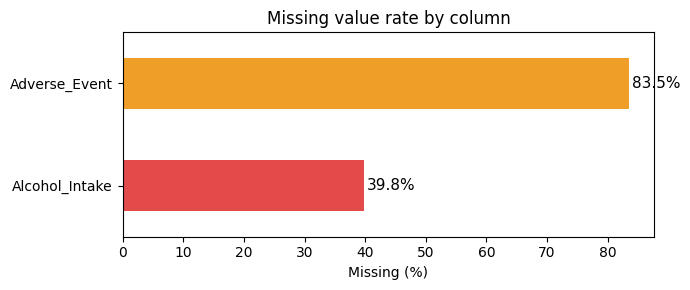

In [ ]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing count'] > 0]
print(missing_df)

# Plot
fig, ax = plt.subplots(figsize=(7, 3))
missing_df['Missing %'].plot(kind='barh', ax=ax, color=['#E24B4A', '#EF9F27'])
ax.set_xlabel('Missing (%)')
ax.set_title('Missing value rate by column')
for i, v in enumerate(missing_df['Missing %']):
    ax.text(v + 0.5, i, f'{v}%', va='center', fontsize=11)
plt.tight_layout()
plt.show()

In [ ]:
df['Adverse_Event_bin'] = df['Adverse_Event'].notna().astype(int)
print('Adverse events (recoded):')
print(df['Adverse_Event_bin'].value_counts())

Adverse events (recoded):
Adverse_Event_bin
0    41736
1     8264
Name: count, dtype: int64


In [ ]:
df['Adverse_Event'] = df['Adverse_Event'].fillna('No Event')
df['Alcohol_Intake'] = df['Alcohol_Intake'].fillna('Non-drinker')

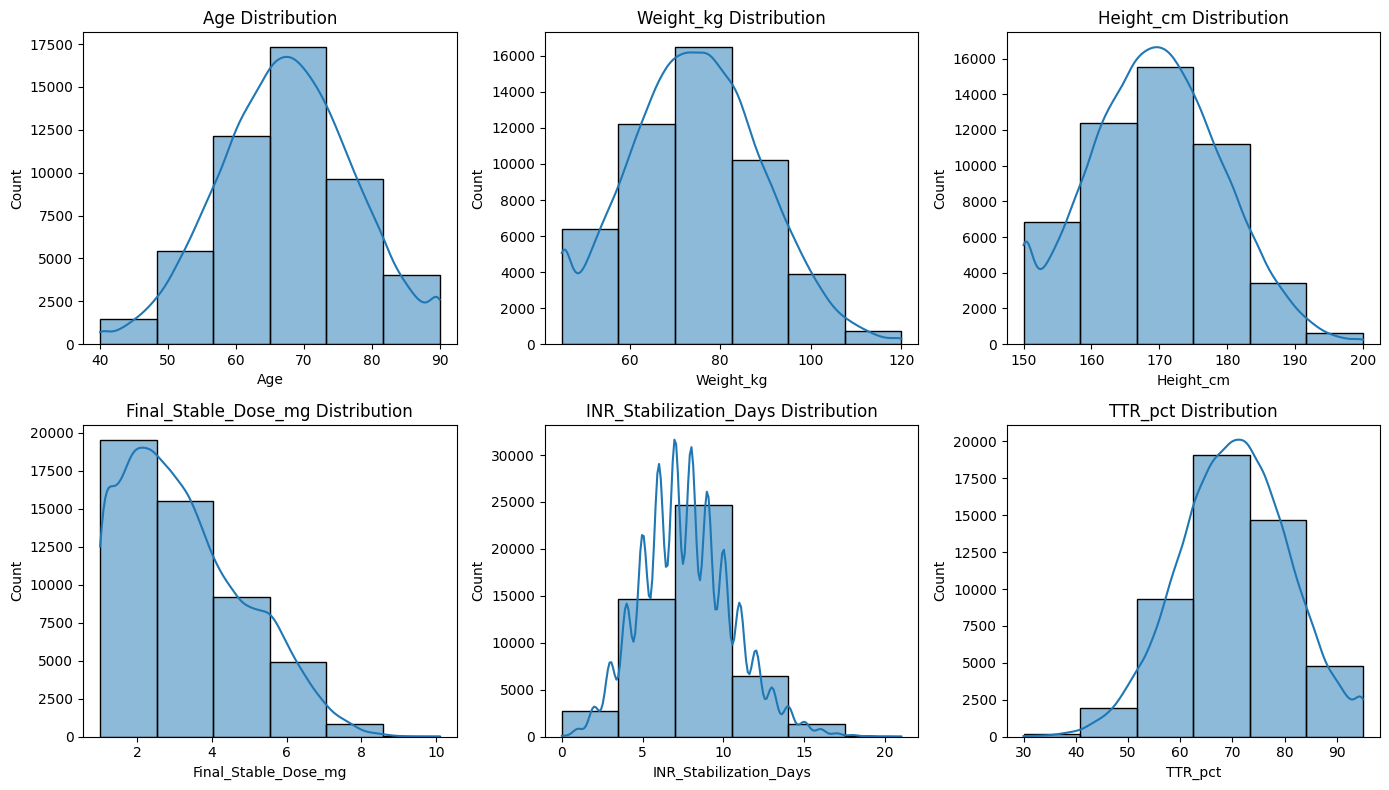

In [ ]:
bins = 6

fig, ax = plt.subplots(2, 3, figsize=(14, 8))

sns.histplot(df['Age'], bins=bins, kde=True, ax=ax[0, 0])
ax[0, 0].set_title('Age Distribution')

sns.histplot(df['Weight_kg'], bins=bins, kde=True, ax=ax[0, 1])
ax[0, 1].set_title('Weight_kg Distribution')

sns.histplot(df['Height_cm'], bins=bins, kde=True, ax=ax[0, 2])
ax[0, 2].set_title('Height_cm Distribution')

sns.histplot(df['Final_Stable_Dose_mg'], bins=bins, kde=True, ax=ax[1, 0])
ax[1, 0].set_title('Final_Stable_Dose_mg Distribution')

sns.histplot(df['INR_Stabilization_Days'], bins=bins, kde=True, ax=ax[1, 1])
ax[1, 1].set_title('INR_Stabilization_Days Distribution')

sns.histplot(df['TTR_pct'], bins=bins, kde=True, ax=ax[1, 2])
ax[1, 2].set_title('TTR_pct Distribution')

plt.tight_layout()
plt.show()

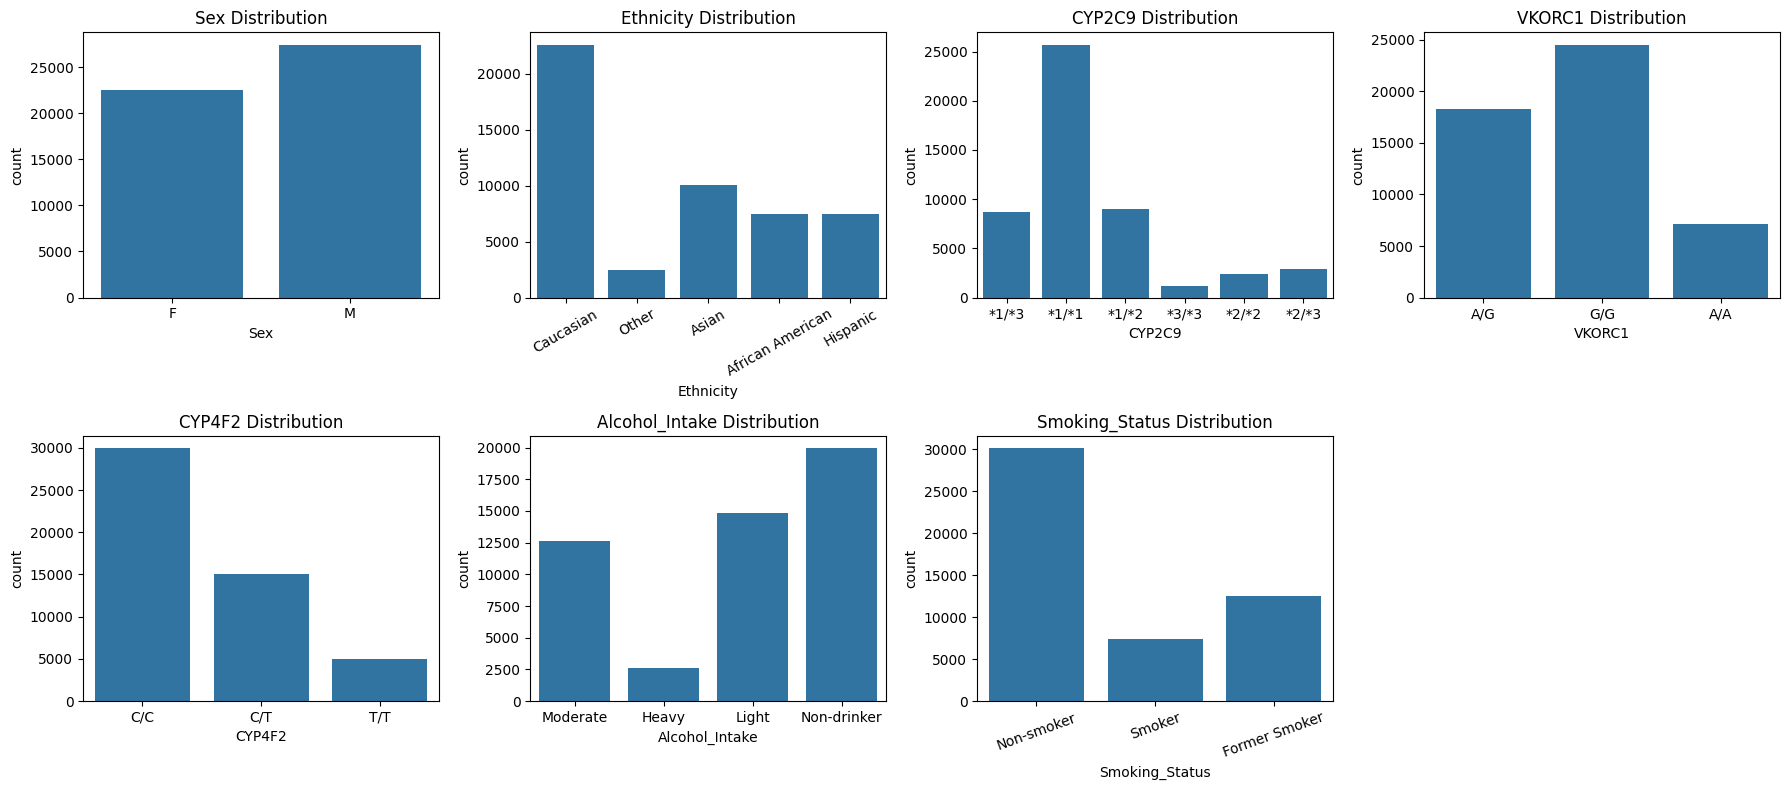

In [ ]:
# Create a 2x4 grid of subplots to fit 7 categorical columns
fig, ax = plt.subplots(2, 4, figsize=(18, 8))

# Plot the count distribution of 'Sex'
sns.countplot(data=df, x='Sex', ax=ax[0, 0])
ax[0, 0].set_title('Sex Distribution')

# Plot the count distribution of 'Ethnicity'
sns.countplot(data=df, x='Ethnicity', ax=ax[0, 1])
ax[0, 1].set_title('Ethnicity Distribution')
ax[0, 1].tick_params(axis='x', rotation=30)

# Plot the count distribution of 'CYP2C9'
sns.countplot(data=df, x='CYP2C9', ax=ax[0, 2])
ax[0, 2].set_title('CYP2C9 Distribution')

# Plot the count distribution of 'VKORC1'
sns.countplot(data=df, x='VKORC1', ax=ax[0, 3])
ax[0, 3].set_title('VKORC1 Distribution')

# Plot the count distribution of 'CYP4F2'
sns.countplot(data=df, x='CYP4F2', ax=ax[1, 0])
ax[1, 0].set_title('CYP4F2 Distribution')

# Plot the count distribution of 'Alcohol_Intake'
sns.countplot(data=df, x='Alcohol_Intake', ax=ax[1, 1])
ax[1, 1].set_title('Alcohol_Intake Distribution')

# Plot the count distribution of 'Smoking_Status'
sns.countplot(data=df, x='Smoking_Status', ax=ax[1, 2])
ax[1, 2].set_title('Smoking_Status Distribution')
ax[1, 2].tick_params(axis='x', rotation=20)

# Hide the unused last subplot
ax[1, 3].set_visible(False)

# Adjust the layout to avoid overlap of plot elements
plt.tight_layout()

# Display the plot
plt.show()


In [ ]:
# Loop through the list of genes and print the normalized value counts for each
for gene in ['CYP2C9', 'VKORC1', 'CYP4F2']:
    print(f'\n{gene} Distribution:\n', df[gene].value_counts(normalize=True))


CYP2C9 Distribution:
 CYP2C9
*1/*1    0.51346
*1/*2    0.18050
*1/*3    0.17480
*2/*3    0.05884
*2/*2    0.04794
*3/*3    0.02446
Name: proportion, dtype: float64

VKORC1 Distribution:
 VKORC1
G/G    0.48998
A/G    0.36638
A/A    0.14364
Name: proportion, dtype: float64

CYP4F2 Distribution:
 CYP4F2
C/C    0.59858
C/T    0.30076
T/T    0.10066
Name: proportion, dtype: float64


In [ ]:
display('Alcohol Intake:', df['Alcohol_Intake'].value_counts(normalize=True))

'Alcohol Intake:'

,proportion
Alcohol_Intake,
Non-drinker,0.39850
Light,0.29662
Moderate,0.25264
Heavy,0.05224


In [ ]:
display('Adverse Events (Percentage):', df['Adverse_Event'].value_counts(normalize=True))
display('Adverse Events (Count):', df['Adverse_Event'].value_counts())

'Adverse Events (Percentage):'

,proportion
Adverse_Event,
No Event,0.83472
Bleeding,0.09568
Clotting,0.06960


'Adverse Events (Count):'

,count
Adverse_Event,
No Event,41736
Bleeding,4784
Clotting,3480


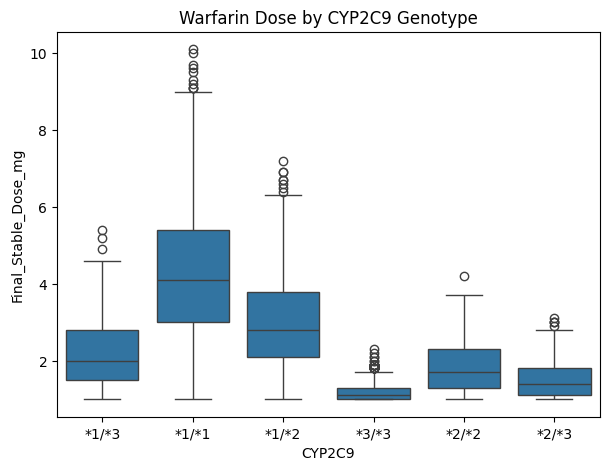

In [ ]:
plt.figure(figsize=(7, 5))

# Plot the boxplot using Seaborn
sns.boxplot(data=df, x='CYP2C9', y='Final_Stable_Dose_mg')
plt.title('Warfarin Dose by CYP2C9 Genotype')
plt.show()

In [ ]:
!pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 2.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 2.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 85.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 68.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 212.0/212.0 kB 18.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 12.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 948.

In [ ]:
import mlflow
import sklearn
import mlflow.sklearn

In [ ]:
pip install category_encoders

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from category_encoders import OneHotEncoder

In [ ]:
df.columns

In [ ]:
features = [
    'Age', 'Sex', 'Weight_kg', 'Height_cm', 'Ethnicity',
    'On_Amiodarone', 'Alcohol_Score', 'VitK_Score'
]

X = df[features]
y = df['Final_Stable_Dose_mg']

In [ ]:
X.head()

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = Pipeline([
            ('ohe', OneHotEncoder(use_cat_names=True)),
            ('dt', DecisionTreeRegressor(random_state=42))])
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [ ]:
mlflow.log_params(model.named_steps['dt'].get_params())
mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})


In [ ]:
mlflow.sklearn.log_model(model, 'model', serialization_format='cloudpickle')

2026/06/30 14:01:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/06/30 14:01:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


In [ ]:
engineered_df = df.copy()

engineered_df["BMI"] = engineered_df["Weight_kg"] / ((engineered_df["Height_cm"] / 100) ** 2)

comorbs = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
engineered_df["Comorbidity_Burden"] = engineered_df[comorbs].sum(axis=1)

meds = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]
engineered_df["Polypharmacy_Index"] = engineered_df[meds].sum(axis=1)

In [ ]:
engineered_df.columns
test_check = engineered_df[['Weight_kg', 'Height_cm', 'BMI']]
test_check.corr()

,Weight_kg,Height_cm,BMI
Weight_kg,1.000000,0.003907,0.857206
Height_cm,0.003907,1.000000,-0.499117
BMI,0.857206,-0.499117,1.000000


In [ ]:
engineered_features = ['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity',
                       'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake',
                       'CYP2C9', 'VKORC1', 'CYP4F2',
                       'On_Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']

In [ ]:
print(engineered_features)

['Age', 'Sex', 'BMI', 'Weight_kg', 'Height_cm', 'Ethnicity', 'Alcohol_Intake', 'Smoking_Status', 'Diet_VitK_Intake', 'CYP2C9', 'VKORC1', 'CYP4F2', 'On_Amiodarone', 'Comorbidity_Burden', 'Polypharmacy_Index']


In [ ]:
X_eng = engineered_df[engineered_features]  # Features (input data)
y_eng = engineered_df['Final_Stable_Dose_mg']  # Target variable (output data)

X_train, X_test, y_train, y_test = train_test_split(X_eng, y_eng, test_size=0.2, random_state=42)
ohe = OneHotEncoder(use_cat_names=True)
X_train_encoded = ohe.fit_transform(X_train)  # Fit and transform the training data
X_test_encoded = ohe.transform(X_test)

In [ ]:
X_train_encoded.columns

Index(['Age', 'Sex_M', 'Sex_F', 'BMI', 'Weight_kg', 'Height_cm',
       'Ethnicity_Caucasian', 'Ethnicity_African American', 'Ethnicity_Asian',
       'Ethnicity_Hispanic', 'Ethnicity_Other', 'Alcohol_Intake_Light',
       'Alcohol_Intake_Non-drinker', 'Alcohol_Intake_Heavy',
       'Alcohol_Intake_Moderate', 'Smoking_Status_Former Smoker',
       'Smoking_Status_Non-smoker', 'Smoking_Status_Smoker',
       'Diet_VitK_Intake_Low', 'Diet_VitK_Intake_High',
       'Diet_VitK_Intake_Medium', 'CYP2C9_*1/*1', 'CYP2C9_*1/*3',
       'CYP2C9_*2/*2', 'CYP2C9_*3/*3', 'CYP2C9_*1/*2', 'CYP2C9_*2/*3',
       'VKORC1_G/G', 'VKORC1_A/G', 'VKORC1_A/A', 'CYP4F2_C/C', 'CYP4F2_C/T',
       'CYP4F2_T/T', 'On_Amiodarone', 'Comorbidity_Burden',
       'Polypharmacy_Index'],
      dtype='object')

In [ ]:
mlflow.end_run()

In [ ]:
with mlflow.start_run(run_name='DecisionTree_Engineered'):
    model = DecisionTreeRegressor(random_state=42)
    model.fit(X_train_encoded, y_train)
    y_pred = model.predict(X_test_encoded)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    mlflow.log_params(model.get_params())
    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})
    mlflow. sklearn.log_model(model, 'model')

2026/06/30 14:01:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [ ]:
with mlflow.start_run(run_name='ExtraTree_Engineered'):

    # Define the model: ExtraTreesRegressor
    # An ExtraTreesRegressor model is used here, with 300 trees (estimators) and no limit on the depth of the trees (max_depth=None)
    # The random_state ensures that results are reproducible
    model = ExtraTreesRegressor(random_state=42, n_estimators=300, max_depth=None)

    # Train the model using the encoded training data (X_train_encoded) and the target variable (y_train)
    # This step trains the model by finding patterns and relationships between the features and the target
    model.fit(X_train_encoded, y_train)

    # Make predictions on the test data (X_test_encoded) using the trained model
    # This step generates predicted values for the target variable on unseen test data
    y_pred = model.predict(X_test_encoded)

    # Evaluate the model performance using several metrics:
    # - MAE (Mean Absolute Error): Measures the average magnitude of errors in predictions, ignoring their direction.
    # - RMSE (Root Mean Squared Error): Penalizes large errors more heavily than MAE and is sensitive to outliers.
    # - R² (Coefficient of Determination): Indicates how well the model explains the variance of the target variable.
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    # Log the model hyperparameters to MLflow
    # This will log all the hyperparameters used in the ExtraTreesRegressor model, allowing you to track the settings for future reference or comparison
    mlflow.log_params(model.get_params())

    # Log the evaluation metrics (MAE, RMSE, and R²) to MLflow
    # These metrics give insight into how well the model is performing, and logging them allows you to compare the results with other models
    mlflow.log_metrics({"mae": mae, "rmse": rmse, "r2": r2})

    # Log the trained model to MLflow
    # The trained ExtraTreesRegressor model is saved to MLflow so that it can be reloaded and used later in the future
    mlflow.sklearn.log_model(model, 'model')

In [ ]:
run_name = 'ExtraTree_Engineered'
run = mlflow.search_runs(filter_string=f"tags.mlflow.runName = '{run_name}'")
model_uri = f"runs:/{run.run_id[0]}/model"
model_name = 'Genexa_Warfarin_Dosing'
mlflow.register_model(model_uri=model_uri, name=model_name)
genexa_model = mlflow.sklearn.load_model("models:/Genexa_Warfarin_Dosing/1")


In [ ]:
pip install lime

In [ ]:
import lime
from lime.lime_tabular import LimeTabularExplainer

explainer = LimeTabularExplainer(
    training_data=X_train_encoded.values,
    feature_names=X_train_encoded.columns,
    class_names=['Final_Stable_Dose_mg'],
    mode='regression'
)

instance = X_test_encoded.iloc[5].values.reshape(1, -1)
explanation = explainer.explain_instance(instance[0], genexa_model.predict)
explanation.show_in_notebook()

In [ ]:
!pip install gradio

In [ ]:
import os
import json
from typing import Dict, List, Tuple
import pandas as pd
import gradio as gr
import category_encoders as ce  # mirrors training encoder

# =========================
# Configuration
# =========================
MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://127.0.0.1:5000")
MODEL_NAME = os.getenv("MODEL_NAME", "Genexa_Warfarin_Dosing")
MODEL_VERSION = os.getenv("MODEL_VERSION", "1")  # or "Production"

DOSE_MIN, DOSE_MAX = 1.0, 10.0
DOSE_STEP = 0.5

In [ ]:
FALLBACK_TRAINED_COLUMNS = [
    "Age", "BMI", "Weight_kg", "Height_cm",
    "Sex_F", "Sex_M",
    "Ethnicity_African American", "Ethnicity_Asian", "Ethnicity_Caucasian", "Ethnicity_Hispanic", "Ethnicity_Other",
    "Alcohol_Intake_Light", "Alcohol_Intake_Moderate", "Alcohol_Intake_Heavy", "Alcohol_Intake_nan",
    "Smoking_Status_Former Smoker", "Smoking_Status_Non-smoker", "Smoking_Status_Smoker",
    "Diet_VitK_Intake_High", "Diet_VitK_Intake_Medium", "Diet_VitK_Intake_Low",
    "CYP2C9_*1/*1", "CYP2C9_*1/*2", "CYP2C9_*1/*3", "CYP2C9_*2/*2", "CYP2C9_*2/*3", "CYP2C9_*3/*3",
    "VKORC1_A/A", "VKORC1_A/G", "VKORC1_G/G",
    "CYP4F2_C/C", "CYP4F2_C/T", "CYP4F2_T/T",
    "On_Amiodarone",
    "Comorbidity_Burden",
    "Polypharamcy_index", "Polypharamcy_Index", "Polypharmacy_Index",
]

In [ ]:
CAT_SPECS = {
    "Sex": ["F", "M"],
    "Ethnicity": ["African American", "Asian", "Caucasian", "Hispanic", "Other"],
    "Alcohol_Intake": ["None", "Light", "Moderate", "Heavy"],
    "Diet_VitK_Intake": ["High", "Medium", "Low"],
    "Smoking_Status": ["Former Smoker", "Non-smoker", "Smoker"],
    "CYP2C9": ["*1/*1", "*1/*2", "*1/*3", "*2/*2", "*2/*3", "*3/*3"],
    "VKORC1": ["A/A", "A/G", "G/G"],
    "CYP4F2": ["C/C", "C/T", "T/T"],
}

In [ ]:
CATEGORICAL_COLS = [
    "Sex", "Ethnicity", "Alcohol_Intake", "Diet_VitK_Intake",
    "Smoking_Status", "CYP2C9", "VKORC1", "CYP4F2",
]

GENE_DEFAULTS = {"CYP2C9": "*1/*1", "VKORC1": "G/G", "CYP4F2": "C/C"}
COMORBS = ["Hypertension", "Diabetes", "Chronic_Kidney_Disease", "Heart_Failure"]
MEDS = ["Amiodarone", "Antibiotics", "Aspirin", "Statins"]

In [ ]:
def clip_and_round(dose: float, step: float = DOSE_STEP) -> float:
    dose = float(np.clip(dose, DOSE_MIN, DOSE_MAX))
    return round(step * round(dose / step), 2)


def ensure_genes(payload: Dict) -> Dict:
    fixed = payload.copy()
    for g, dflt in GENE_DEFAULTS.items():
        if fixed.get(g) in [None, "", "NA", "Unknown"]:
            fixed[g] = dflt
    return fixed

In [ ]:
def engineer_single(example: Dict) -> pd.DataFrame:
    ex = ensure_genes(example)
    row = {
        "Age": ex.get("Age"),
        "Weight_kg": ex.get("Weight_kg"),
        "Height_cm": ex.get("Height_cm"),
        "Sex": ex.get("Sex"),
        "Ethnicity": ex.get("Ethnicity"),
        "Alcohol_Intake": ex.get("Alcohol_Intake"),
        "Diet_VitK_Intake": ex.get("Diet_VitK_Intake"),
        "Smoking_Status": ex.get("Smoking_Status"),
        "CYP2C9": ex.get("CYP2C9"),
        "VKORC1": ex.get("VKORC1"),
        "CYP4F2": ex.get("CYP4F2"),
        "On_Amiodarone": int(ex.get("Amiodarone", 0) or ex.get("On_Amiodarone", 0)),
    }
    for c in COMORBS:
        row[c] = int(ex.get(c, 0))
    for m in MEDS:
        row[m] = int(ex.get(m, 0))

    df = pd.DataFrame([row])

    for col, cats in CAT_SPECS.items():
          if col in df.columns:
            df[col] = pd.Categorical(df[col], categories=cats, ordered=False)

    df["BMI"] = df["Weight_kg"] / ((df["Height_cm"] / 100.0) ** 2)
    df["Comorbidity_Burden"] = df[COMORBS].sum(axis=1)
    df["Polypharmacy_Index"] = df[MEDS].sum(axis=1)
    df["Polypharamcy_Index"] = df["Polypharmacy_Index"]
    df["Polypharamcy_index"] = df["Polypharmacy_Index"]

    engineered_cols = [
        "Age", "Weight_kg", "Height_cm", "Sex", "Ethnicity",
        "Alcohol_Intake", "Diet_VitK_Intake", "Smoking_Status",
        "CYP2C9", "VKORC1", "CYP4F2", "On_Amiodarone",
        "BMI", "Comorbidity_Burden",
        "Polypharmacy_Index", "Polypharamcy_Index", "Polypharamcy_index",
    ]
    return df[engineered_cols]

In [ ]:
def load_trained_columns(model) -> List[str]:
    if os.path.exists("trained_columns.json"):
        try:
            with open("trained_columns.json", "r") as f:
                cols = json.load(f)
            if isinstance(cols, list) and len(cols) > 0:
                return cols
        except Exception:
            pass
    try:
        cols = list(model.feature_names_in_)
        if len(cols) > 0:
            return cols
    except Exception:
        pass
    return FALLBACK_TRAINED_COLUMNS

In [ ]:
def to_model_matrix(df_one: pd.DataFrame, trained_columns: List[str]) -> pd.DataFrame:
    enc = ce.OneHotEncoder(
        cols=CATEGORICAL_COLS,
        use_cat_names=True,
        handle_unknown="ignore",
        handle_missing="value"
    )
    X = enc.fit_transform(df_one)
    X = X.reindex(columns=trained_columns, fill_value=0)
    return X